In [3]:
import urllib.request
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

image_path = "data/train/images/img_00001.jpg"

In [ ]:
# Initialize the model (it will download a ~6MB weights file automatically)
model = YOLO('yolo12x.pt') 

# Finetune the model the model
results = model.tune(
    data="SKU-110K.yaml", 
    epochs=30,
    iterations=300,
    optimizer="AdamW", 
    imgsz=1536,
    batch=-1,
    device=0,
    amp=True,        # CRITICAL for V100 speed (Automatic Mixed Precision)
    project='norgesgruppen',
    name='yolo12x_sku110k_v100'
)

Ultralytics 8.4.24 🚀 Python-3.11.8 torch-2.10.0 CPU (Apple M1)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=SKU-110K.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1536, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrain

KeyboardInterrupt: 

In [ ]:
# Run inference. 
results = model(image_path, conf=0.1, iou=0.5, max_det=1000, agnostic_nms=True, imgsz=1536)

# Extract the first result (since we only passed one image)
result = results[0]
print(f"YOLO found {len(result.boxes)} objects!")

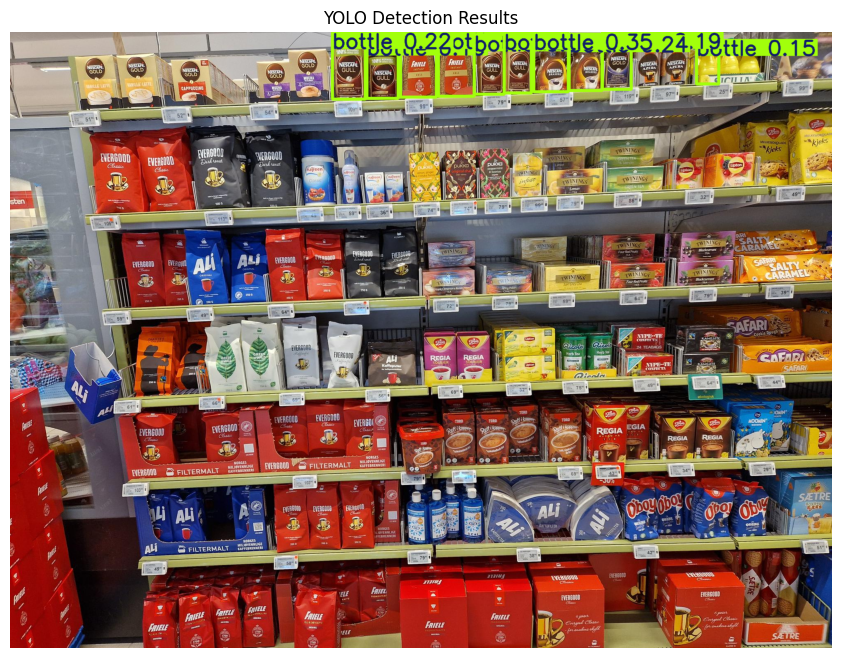

In [ ]:
# .plot() returns a numpy array (BGR format for OpenCV)
annotated_img = result.plot()

# Convert BGR (OpenCV standard) to RGB (Matplotlib standard)
annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

# Display the image
plt.figure(figsize=(12, 8))
plt.imshow(annotated_img_rgb)
plt.axis('off')
plt.title("YOLO Detection Results")
plt.show()

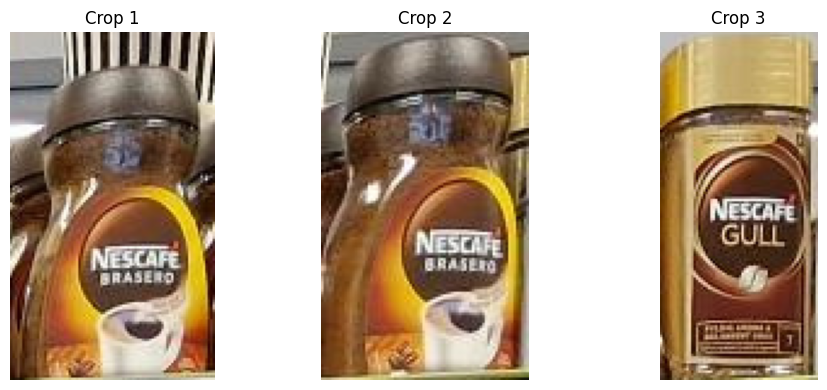

In [ ]:
# Load the original image using OpenCV
original_img = cv2.imread(image_path)
original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

# Extract the bounding boxes as a numpy array
# Format is[x_min, y_min, x_max, y_max]
boxes = result.boxes.xyxy.cpu().numpy()

# Let's plot the original image alongside the first 3 cropped products
num_crops_to_show = min(3, len(boxes))
fig, axes = plt.subplots(1, num_crops_to_show, figsize=(10, 4))

for i in range(num_crops_to_show):
    # Get coordinates and convert to integers
    x1, y1, x2, y2 = map(int, boxes[i])
    
    # Crop the image array: image[y_start:y_end, x_start:x_end]
    cropped_product = original_img_rgb[y1:y2, x1:x2]
    
    # Display the crop
    ax = axes[i] if num_crops_to_show > 1 else axes
    ax.imshow(cropped_product)
    ax.set_title(f"Crop {i+1}")
    ax.axis('off')

plt.tight_layout()
plt.show()